# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

In [ ]:
!unzip -o /content/Data.zip -d /content

Archive:  /content/Data.zip
   creating: /content/Data/
   creating: /content/Data/EEG/
   creating: /content/Data/EEG/1030/
  inflating: /content/Data/EEG/1030/eeg_baseline_level_1.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_2.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_3.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_4.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_5.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_6.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_7.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_8.csv  
  inflating: /content/Data/EEG/1030/eeg_baseline_level_9.csv  
  inflating: /content/Data/EEG/1030/eeg_data_level_1.csv  
  inflating: /content/Data/EEG/1030/eeg_data_level_2.csv  
  inflating: /content/Data/EEG/1030/eeg_data_level_3.csv  
  inflating: /content/Data/EEG/1030/eeg_data_level_4.csv  
  inflating: /content/Data/EEG/1030/eeg_data_level_5.csv  
  inflating: 

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse

dérive lente basse fréquence, bruit secteur (60 Hz au Canada), bruit haute fréquence

## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse

Le signal synthétique est construit avec des composantes connues exactement (fréquences, amplitudes). On peut donc vérifier que le filtre supprime précisément ce qu'il doit supprimer (la dérive à 0.2 Hz, le pic à 60 Hz) et conserve ce qu'il doit conserver (10 Hz, 25 Hz). Sur un signal EEG réel, on ne connaît pas la vérité terrain fréquentielle, donc la validation est impossible.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

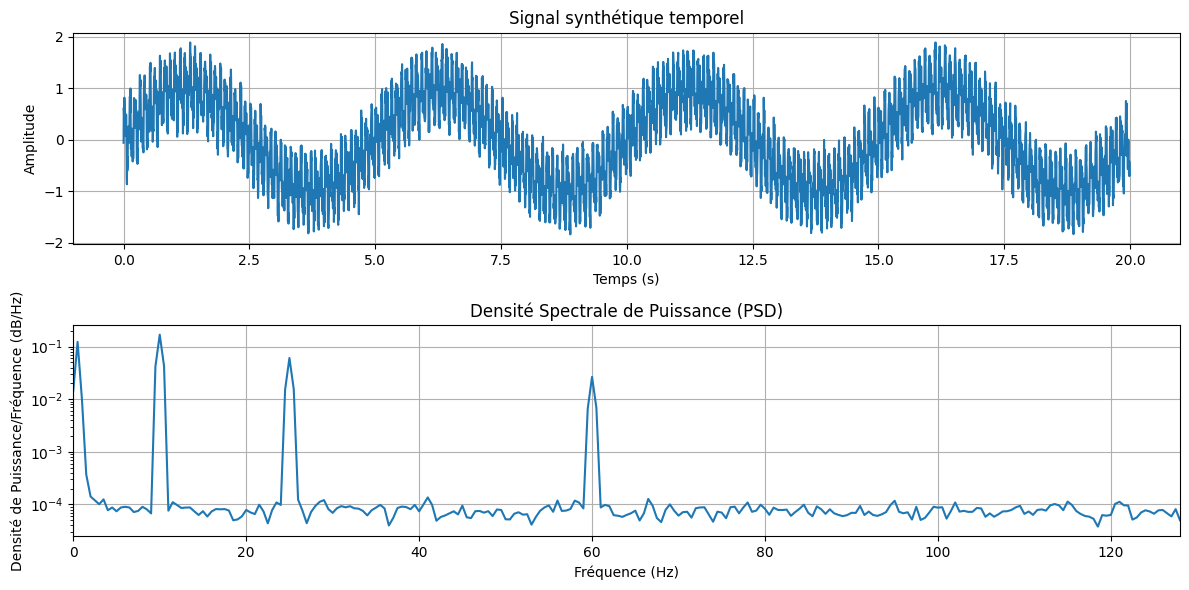

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
fs = 256
duration = 20
t = np.arange(0, duration, 1/fs)
signal = np.zeros_like(t)
signal += np.sin(2 * np.pi * 0.2 * t)
signal += 0.5 * np.sin(2 * np.pi * 10 * t)
signal += 0.3 * np.sin(2 * np.pi * 25 * t)
signal += 0.2 * np.sin(2 * np.pi * 60 * t)
signal += 0.1 * np.random.normal(size=t.shape)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Signal synthétique temporel')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
freqs, psd = welch(signal, fs=fs, nperseg=fs*2)
plt.subplot(2, 1, 2)
plt.semilogy(freqs, psd)
plt.title('Densité Spectrale de Puissance (PSD)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conserve les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse

filtfilt applique le filtre deux fois (aller et retour), ce qui annule le déphasage introduit par le filtre.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse

Fn​=256/2​=128 Hz

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

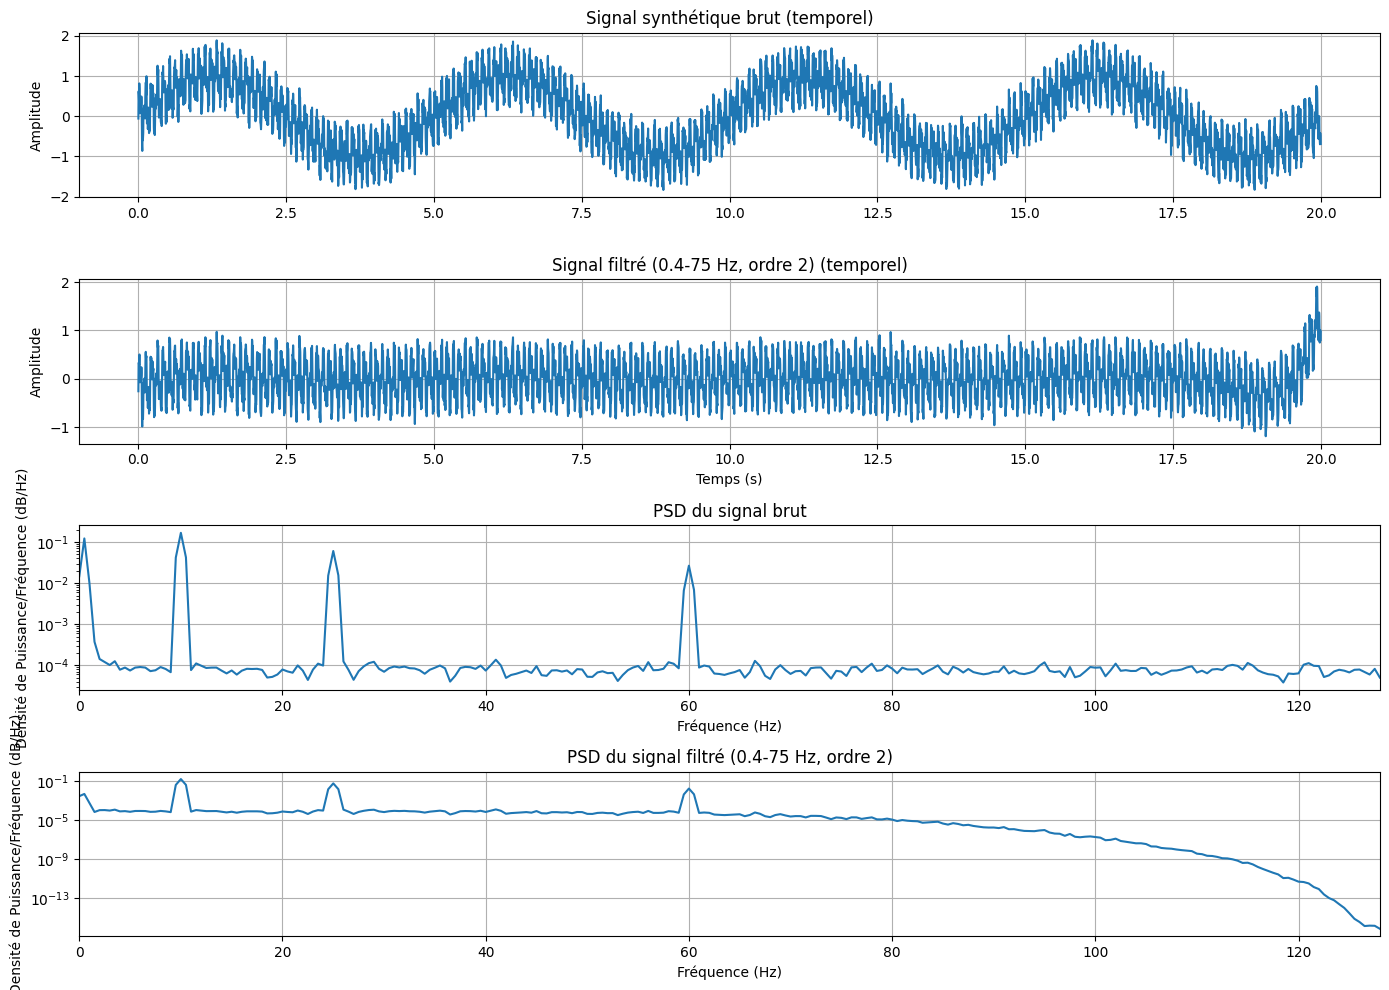

In [ ]:
from scipy.signal import butter, sosfiltfilt

def bandpass_filter(signal, fs, lowcut, highcut, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], analog=False, btype='band', output='sos')
    filtered_signal = sosfiltfilt(sos, signal)
    return filtered_signal
lowcut = 0.4
highcut = 75
order = 2
signal_filtered = bandpass_filter(signal, fs, lowcut, highcut, order)
plt.figure(figsize=(14, 10))
plt.subplot(4, 1, 1)
plt.plot(t, signal)
plt.title('Signal synthétique brut (temporel)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(t, signal_filtered)
plt.title(f'Signal filtré ({lowcut}-{highcut} Hz, ordre {order}) (temporel)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
freqs_orig, psd_orig = welch(signal, fs=fs, nperseg=fs*2)
plt.subplot(4, 1, 3)
plt.semilogy(freqs_orig, psd_orig)
plt.title('PSD du signal brut')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.grid(True)
freqs_filt, psd_filt = welch(signal_filtered, fs=fs, nperseg=fs*2)
plt.subplot(4, 1, 4)
plt.semilogy(freqs_filt, psd_filt)
plt.title(f'PSD du signal filtré ({lowcut}-{highcut} Hz, ordre {order})')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse

 les données ont été collectées à Queen's University, Canada. Le réseau électrique nord-américain est à 60 Hz. En France, le réseau est à 50 Hz. Le choix du notch dépend donc du pays d'acquisition, pas du pays d'utilisation.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse

Si le signal ne contient pas de pic secteur visible (capteurs bien isolés, équipement sur batterie), le notch supprime inutilement une bande fréquentielle qui peut contenir de l'information EEG réelle (la bande gamma débute à 31 Hz, et à 60 Hz on est en plein gamma). Il faut d'abord inspecter la PSD pour décider si le notch est nécessaire.

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

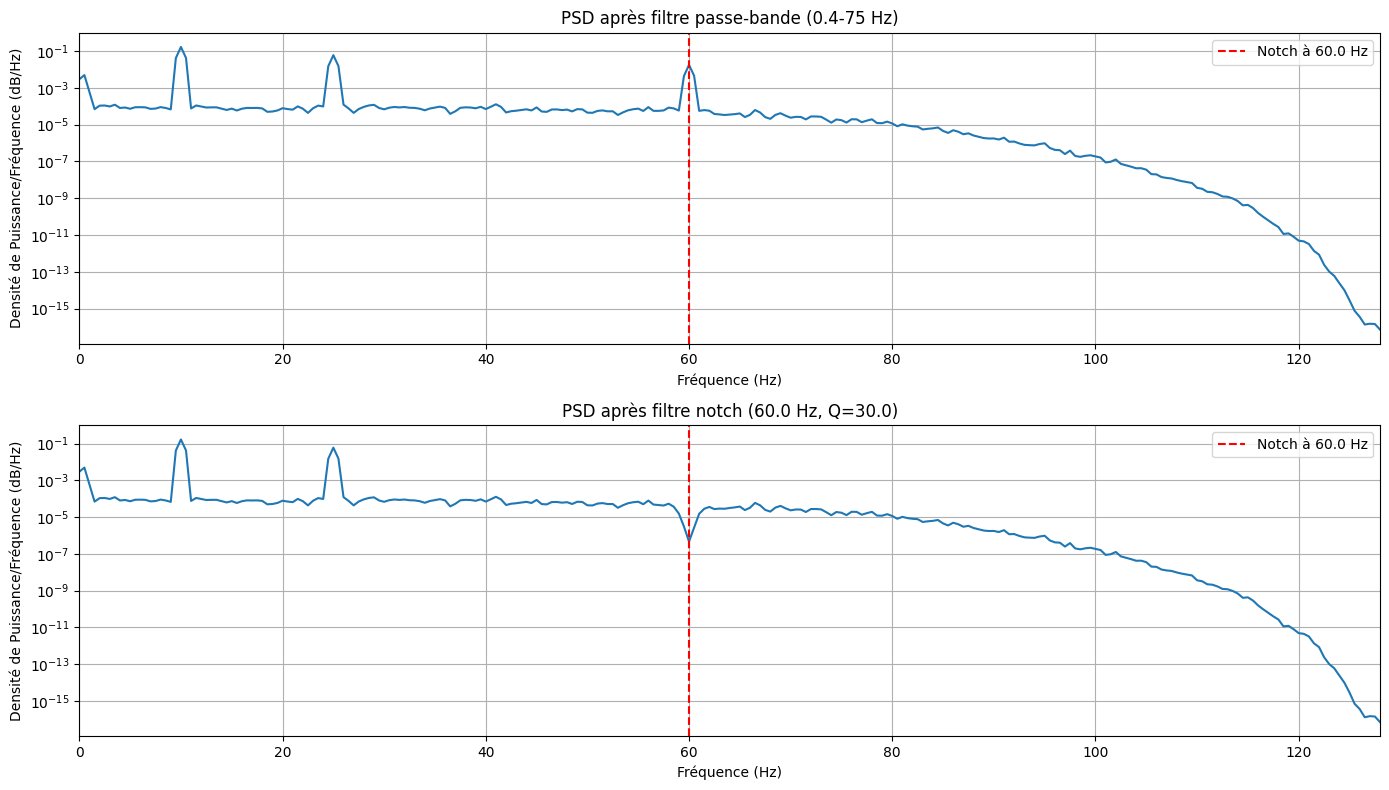

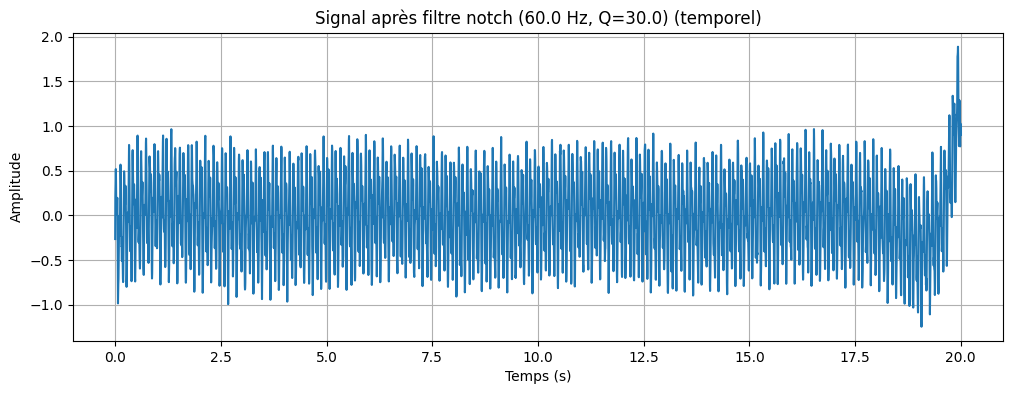

In [ ]:
from scipy.signal import iirnotch, filtfilt

notch_freq = 60.0
Q = 30.0
b, a = iirnotch(notch_freq, Q, fs)
signal_notch_filtered = filtfilt(b, a, signal_filtered)
plt.figure(figsize=(14, 8))
freqs_bp, psd_bp = welch(signal_filtered, fs=fs, nperseg=fs*2)
plt.subplot(2, 1, 1)
plt.semilogy(freqs_bp, psd_bp)
plt.title(f'PSD après filtre passe-bande ({lowcut}-{highcut} Hz)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.axvline(x=notch_freq, color='r', linestyle='--', label=f'Notch à {notch_freq} Hz')
plt.grid(True)
plt.legend()
freqs_notch, psd_notch = welch(signal_notch_filtered, fs=fs, nperseg=fs*2)
plt.subplot(2, 1, 2)
plt.semilogy(freqs_notch, psd_notch)
plt.title(f'PSD après filtre notch ({notch_freq} Hz, Q={Q})')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.axvline(x=notch_freq, color='r', linestyle='--', label=f'Notch à {notch_freq} Hz')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(t, signal_notch_filtered)
plt.title(f'Signal après filtre notch ({notch_freq} Hz, Q={Q}) (temporel)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt
def _bandpass_filter(signal, fs, lowcut, highcut, order):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], analog=False, btype='band', output='sos')
    filtered_signal = sosfiltfilt(sos, signal)
    return filtered_signal

def preprocess_eeg_1d(eeg_signal,
                      fs=256,
                      lowcut=0.4,
                      highcut=75,
                      order=2,
                      notch_freq=60,
                      quality_factor=30):

    eeg_signal_np = np.asarray(eeg_signal, dtype=float)
    eeg_series = pd.Series(eeg_signal_np)
    eeg_series_interpolated = eeg_series.interpolate(method='linear', limit_direction='both', limit=fs)
    eeg_signal_processed = eeg_series_interpolated.fillna(eeg_series_interpolated.mean()).to_numpy()
    eeg_signal_bandpass = _bandpass_filter(eeg_signal_processed, fs, lowcut, highcut, order)
    b, a = iirnotch(notch_freq, quality_factor, fs)
    eeg_signal_notch = filtfilt(b, a, eeg_signal_bandpass)
    return eeg_signal_notch

### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse

Le filtre passe-bande est configuré avec une fréquence de coupure basse (`lowcut`) de 0.4 Hz. Par conséquent, la dérive lente à 0.2 Hz, étant en dessous de cette fréquence de coupure, devrait être fortement atténuée ou supprimée par le filtre.

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse

Le filtre notch crée une encoche très étroite centrée à 60 Hz (facteur de qualité Q=30, papier page 7 : "notch filter with a quality factor of 30"). La puissance à 60 Hz est donc fortement réduite, tandis que les fréquences voisines sont peu affectées.

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse

La fréquence de Nyquist est 128 Hz. 75 Hz < 128 Hz, donc la condition de Shannon-Nyquist est respectée : on peut représenter et filtrer des composantes jusqu'à 75 Hz sans aliasing avec une fréquence d'échantillonnage de 256 Hz.

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse

Le filtre tente de couper au-delà de la fréquence de Nyquist, ce qui est physiquement impossible avec un signal numérique. scipy.signal.butter lève une erreur (ValueError) car la fréquence normalisée dépasse 1.0.

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

In [ ]:
import pandas as pd
import numpy as np

def preprocess_eeg_dataframe(df,
                           eeg_channels=['AF7', 'AF8', 'TP9', 'TP10'],
                           time_col='Time',
                           fs=256,
                           lowcut=0.4,
                           highcut=75,
                           order=2,
                           notch_freq=60,
                           quality_factor=30):

    df_processed = df.copy()
    time_data = None
    if time_col and time_col in df_processed.columns:
        time_data = df_processed[time_col]
        if time_col in eeg_channels:
            eeg_channels.remove(time_col)
    available_eeg_channels = [col for col in eeg_channels if col in df_processed.columns]
    if not available_eeg_channels:
        print("Warning: No specified EEG channels found in the DataFrame. Applying to all numeric columns except time_col.")
        numeric_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
        if time_col and time_col in numeric_cols:
            numeric_cols.remove(time_col)
        available_eeg_channels = numeric_cols
        if not available_eeg_channels:
            raise ValueError("No numeric columns to preprocess.")
    for channel in available_eeg_channels:
        df_processed[channel] = preprocess_eeg_1d(df_processed[channel].values,
                                                  fs=fs,
                                                  lowcut=lowcut,
                                                  highcut=highcut,
                                                  order=order,
                                                  notch_freq=notch_freq,
                                                  quality_factor=quality_factor)
    if time_data is not None:
        df_processed[time_col] = time_data
        cols = [time_col] + [col for col in df_processed.columns if col != time_col]
        df_processed = df_processed[cols]
    return df_processed

## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

Fichier chargé: eeg_data_level_1.csv
Premières lignes du DataFrame brut:
     Timestamp          TP9          AF7          AF8        TP10
0  120.0078125     -39.0625 -10.25390625 -28.80859375 -10.7421875
1 120.01171875  -24.4140625  -2.44140625     -23.4375 -10.7421875
2   120.015625    -5.859375  -10.7421875  -5.37109375 -4.39453125
3 120.01953125 -31.73828125 -23.92578125  10.25390625   -9.765625
4  120.0234375 -27.83203125 -20.99609375  -8.30078125    11.71875
Colonnes disponibles: ['Timestamp', 'TP9', 'AF7', 'AF8', 'TP10']


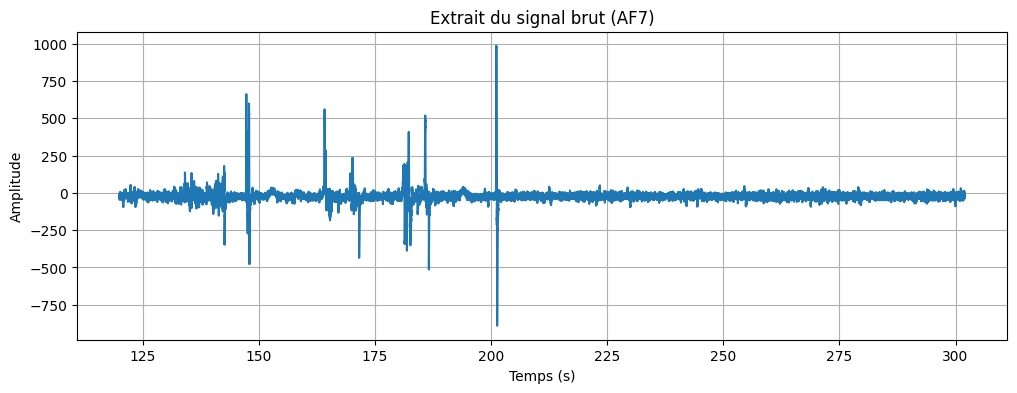

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

eeg_filepath = Path('/content/Data/EEG/1030/eeg_data_level_1.csv')
df_eeg_raw = pd.read_csv(eeg_filepath)
print(f"Fichier chargé: {eeg_filepath.name}")
print("Premières lignes du DataFrame brut:")
original_float_format = pd.get_option('display.float_format')
pd.set_option('display.float_format', str)
print(df_eeg_raw.head())
pd.set_option('display.float_format', original_float_format)
print("Colonnes disponibles:", df_eeg_raw.columns.tolist())
eeg_channels = ['AF7', 'AF8', 'TP9', 'TP10']
plt.figure(figsize=(12, 4))
plt.plot(df_eeg_raw['Timestamp'], df_eeg_raw['AF7'])
plt.title('Extrait du signal brut (AF7)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

Premières lignes du DataFrame prétraité:
    Timestamp        TP9        AF7        AF8       TP10
0  120.007812  -1.990833 -10.128303   8.769133  -0.892351
1  120.011719  14.320608  -4.517761  15.337568  -0.107444
2  120.015625  20.500738 -10.328422  31.705631  -1.336816
3  120.019531  12.993641 -19.734923  40.361976   7.110694
4  120.023438  15.674398 -17.639489  32.959161  19.746439


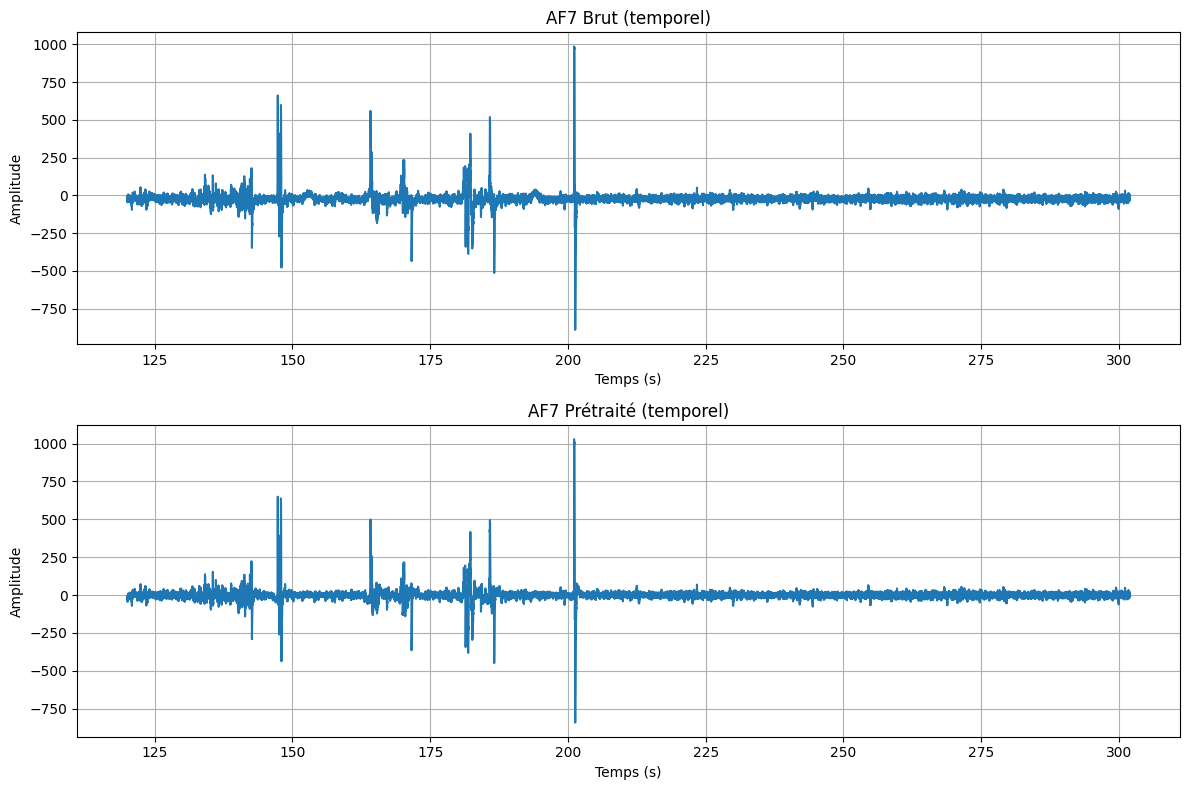

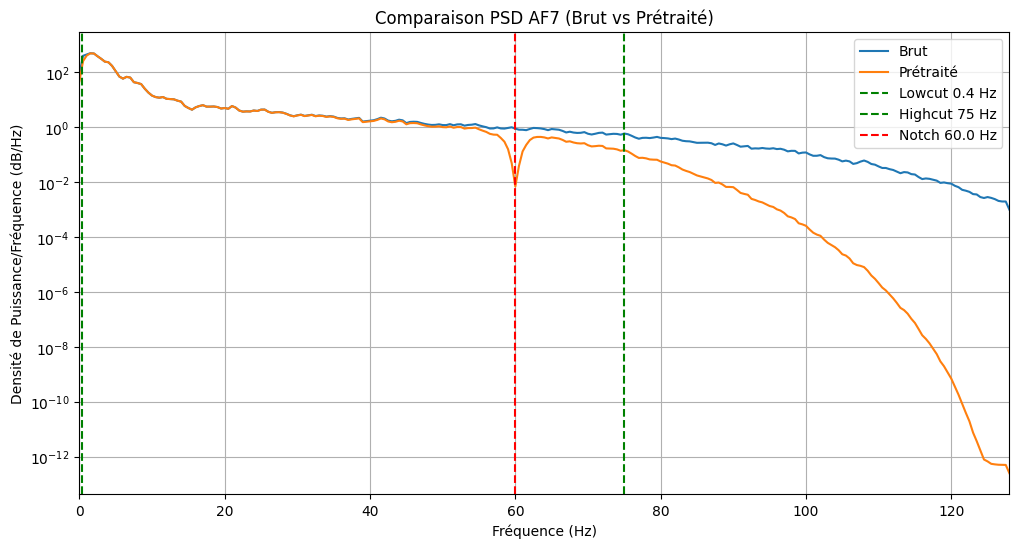

In [ ]:

df_eeg_processed = preprocess_eeg_dataframe(df_eeg_raw.copy(), fs=fs, lowcut=lowcut, highcut=highcut, order=order, notch_freq=notch_freq, quality_factor=Q, time_col='Timestamp')

print("Premières lignes du DataFrame prétraité:")
print(df_eeg_processed.head())


plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(df_eeg_raw['Timestamp'], df_eeg_raw['AF7'])
plt.title('AF7 Brut (temporel)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_eeg_processed['Timestamp'], df_eeg_processed['AF7'])
plt.title('AF7 Prétraité (temporel)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


freqs_raw, psd_raw = welch(df_eeg_raw['AF7'].values, fs=fs, nperseg=fs*2)
freqs_processed, psd_processed = welch(df_eeg_processed['AF7'].values, fs=fs, nperseg=fs*2)

plt.figure(figsize=(12, 6))
plt.semilogy(freqs_raw, psd_raw, label='Brut')
plt.semilogy(freqs_processed, psd_processed, label='Prétraité')
plt.title('Comparaison PSD AF7 (Brut vs Prétraité)')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Densité de Puissance/Fréquence (dB/Hz)')
plt.xlim(0, fs / 2)
plt.axvline(x=lowcut, color='g', linestyle='--', label=f'Lowcut {lowcut} Hz')
plt.axvline(x=highcut, color='g', linestyle='--', label=f'Highcut {highcut} Hz')
plt.axvline(x=notch_freq, color='r', linestyle='--', label=f'Notch {notch_freq} Hz')
plt.grid(True)
plt.legend()
plt.show()


### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse

Le domaine temporel montre la dérive et les artefacts visibles dans l'amplitude. Le domaine fréquentiel (PSD) confirme si les composantes parasites (60 Hz, basse fréquence) ont bien été supprimées et si les bandes utiles (delta, theta, alpha, beta, gamma) sont préservées. Les deux vues sont complémentaires.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse

Une interpolation sur 30 secondes produirait des données artificielles qui n'ont aucune relation avec l'activité cérébrale réelle, ce qui biaiserait l'apprentissage.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse

Si le prétraitement diffère entre train et test, la distribution des features change entre les deux ensembles. Le modèle entraîné sur des features issues d'un prétraitement A ne généralise pas correctement sur des features issues d'un prétraitement B. Cela crée une fuite de données ou une dégradation artificielle des performances.

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.


--- EEG Quality Report after Preprocessing ---

1. NaN Check:
   - NaN values in raw DataFrame: 0
   - NaN values in processed DataFrame: 0
   Status: No NaN values found in processed data. (OK)

2. Length Check:
   - Length of raw DataFrame: 46594
   - Length of processed DataFrame: 46594
   Status: Length unchanged. (OK)

--- Channel: AF7 ---
3. Amplitude Range:
   - Min Amplitude: -841.15 µV
   - Max Amplitude: 1028.39 µV
   Status: WARNING - Amplitudes outside expected range (-500, 500).
4. Standard Deviation:
   - Std Dev: 43.47
   Status: Standard deviation is non-zero. (OK)
5. PSD Coherence (Visual Inspection Recommended): 
   - WARNING: Notch filter at 60.0 Hz might not be fully effective (power changed from 8.85e-01 to 1.86e-01).
   - WARNING: Low-frequency filter below 0.4 Hz might not be fully effective (power changed from 8.34e+01 to 4.76e+01).


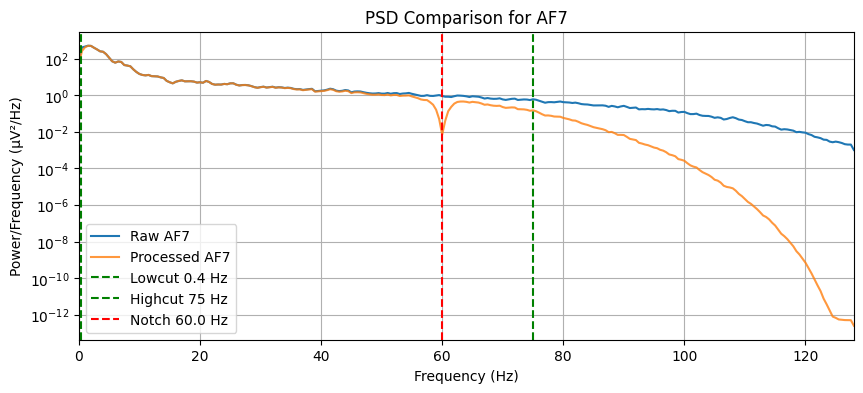


--- Channel: AF8 ---
3. Amplitude Range:
   - Min Amplitude: -833.07 µV
   - Max Amplitude: 1028.07 µV
   Status: WARNING - Amplitudes outside expected range (-500, 500).
4. Standard Deviation:
   - Std Dev: 47.26
   Status: Standard deviation is non-zero. (OK)
5. PSD Coherence (Visual Inspection Recommended): 
   - WARNING: Notch filter at 60.0 Hz might not be fully effective (power changed from 1.82e+00 to 3.76e-01).
   - WARNING: Low-frequency filter below 0.4 Hz might not be fully effective (power changed from 1.07e+02 to 6.25e+01).


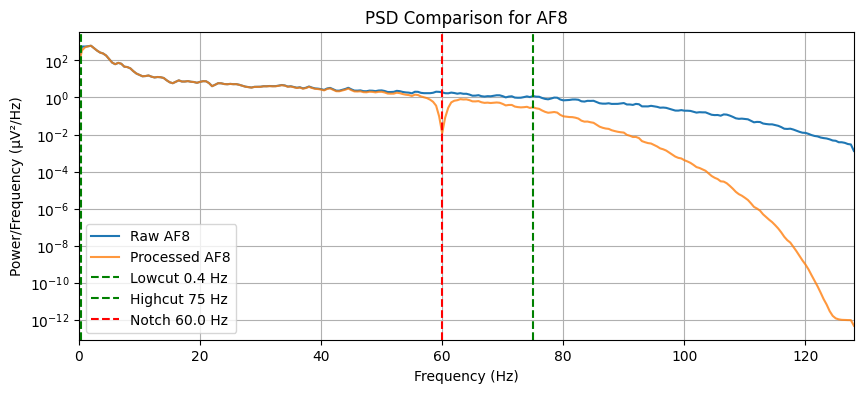


--- Channel: TP9 ---
3. Amplitude Range:
   - Min Amplitude: -826.75 µV
   - Max Amplitude: 1045.43 µV
   Status: WARNING - Amplitudes outside expected range (-500, 500).
4. Standard Deviation:
   - Std Dev: 62.86
   Status: Standard deviation is non-zero. (OK)
5. PSD Coherence (Visual Inspection Recommended): 
   - Notch filter at 60.0 Hz appears effective (power reduced from 2.38e+00 to 4.52e-01). (OK)
   - WARNING: Low-frequency filter below 0.4 Hz might not be fully effective (power changed from 2.39e+02 to 1.25e+02).


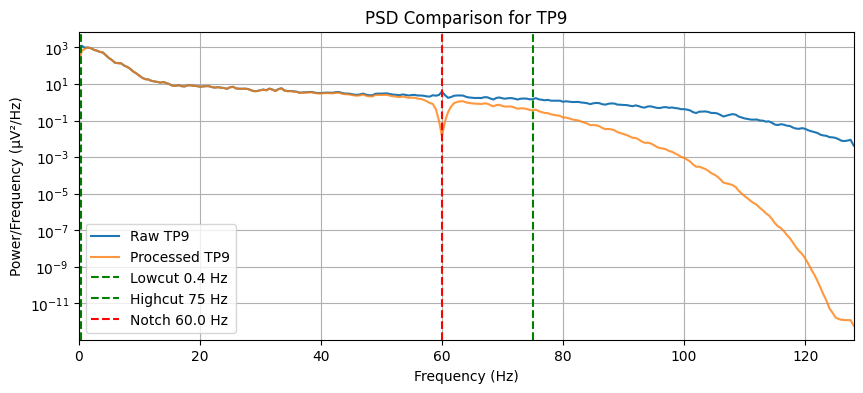


--- Channel: TP10 ---
3. Amplitude Range:
   - Min Amplitude: -776.24 µV
   - Max Amplitude: 1017.89 µV
   Status: WARNING - Amplitudes outside expected range (-500, 500).
4. Standard Deviation:
   - Std Dev: 62.91
   Status: Standard deviation is non-zero. (OK)
5. PSD Coherence (Visual Inspection Recommended): 
   - Notch filter at 60.0 Hz appears effective (power reduced from 3.49e+00 to 6.94e-01). (OK)
   - WARNING: Low-frequency filter below 0.4 Hz might not be fully effective (power changed from 1.41e+02 to 9.00e+01).


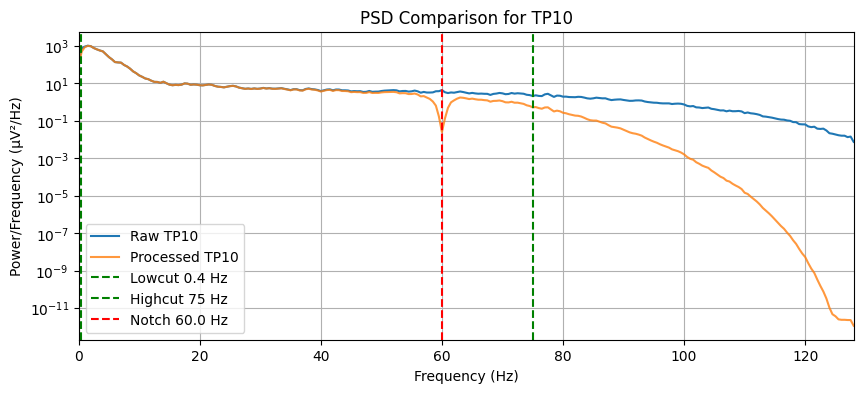


6. Decision on segment exclusion:
   - This step requires expert knowledge or further automated artifact detection.
   - Segments with extreme amplitudes, zero standard deviation, or persistent noise after preprocessing should be considered for exclusion or further processing.
   - Review the amplitude ranges and PSD plots above for indications of degraded segments.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

def eeg_quality_report(df_raw, df_processed, eeg_channels, fs, lowcut, highcut, notch_freq, time_col='Timestamp', amplitude_range=(-500, 500)):

    print("\n--- EEG Quality Report after Preprocessing ---")


    nan_in_raw = df_raw.isnull().sum().sum()
    nan_in_processed = df_processed.isnull().sum().sum()
    print(f"\n1. NaN Check:")
    print(f"   - NaN values in raw DataFrame: {nan_in_raw}")
    print(f"   - NaN values in processed DataFrame: {nan_in_processed}")
    if nan_in_processed == 0:        print("   Status: No NaN values found in processed data. (OK)")
    else:
        print("   Status: WARNING - NaN values still present in processed data.")


    len_raw = len(df_raw)
    len_processed = len(df_processed)
    print(f"\n2. Length Check:")
    print(f"   - Length of raw DataFrame: {len_raw}")
    print(f"   - Length of processed DataFrame: {len_processed}")
    if len_raw == len_processed:
        print("   Status: Length unchanged. (OK)")
    else:
        print("   Status: ERROR - Length changed after processing.")


    for channel in eeg_channels:
        if channel not in df_processed.columns:
            print(f"\n   Channel '{channel}' not found in processed DataFrame. Skipping detailed checks.")
            continue

        print(f"\n--- Channel: {channel} ---")

        signal_processed = df_processed[channel].values


        min_amp = np.min(signal_processed)
        max_amp = np.max(signal_processed)
        print(f"3. Amplitude Range:")
        print(f"   - Min Amplitude: {min_amp:.2f} µV")
        print(f"   - Max Amplitude: {max_amp:.2f} µV")
        if amplitude_range[0] <= min_amp and max_amp <= amplitude_range[1]:
            print("   Status: Amplitudes within typical range. (OK)")
        else:
            print(f"   Status: WARNING - Amplitudes outside expected range {amplitude_range}.")


        std_dev = np.std(signal_processed)
        print(f"4. Standard Deviation:")
        print(f"   - Std Dev: {std_dev:.2f}")
        if std_dev > 0:
            print("   Status: Standard deviation is non-zero. (OK)")
        else:
            print("   Status: ERROR - Standard deviation is zero. Signal might be flat.")


        print("5. PSD Coherence (Visual Inspection Recommended): ")


        raw_channel_data = df_raw[channel].values
        freqs_raw, psd_raw = welch(raw_channel_data, fs=fs, nperseg=fs*2)
        freqs_processed, psd_processed = welch(signal_processed, fs=fs, nperseg=fs*2)


        if notch_freq is not None:

            notch_freq_idx_raw = np.where((freqs_raw >= notch_freq - 2) & (freqs_raw <= notch_freq + 2))
            notch_power_raw = np.mean(psd_raw[notch_freq_idx_raw]) if notch_freq_idx_raw[0].size > 0 else 0

            notch_freq_idx_processed = np.where((freqs_processed >= notch_freq - 2) & (freqs_processed <= notch_freq + 2))
            notch_power_processed = np.mean(psd_processed[notch_freq_idx_processed]) if notch_freq_idx_processed[0].size > 0 else 0

            if notch_power_raw > 0 and notch_power_processed < notch_power_raw * 0.2:
                print(f"   - Notch filter at {notch_freq} Hz appears effective (power reduced from {notch_power_raw:.2e} to {notch_power_processed:.2e}). (OK)")
            elif notch_power_raw > 0:
                print(f"   - WARNING: Notch filter at {notch_freq} Hz might not be fully effective (power changed from {notch_power_raw:.2e} to {notch_power_processed:.2e}).")
            else:
                print(f"   - No significant {notch_freq} Hz peak detected in raw data.")


        lowcut_freq_idx_raw = np.where(freqs_raw < lowcut + 0.1)
        low_power_raw = np.mean(psd_raw[lowcut_freq_idx_raw]) if lowcut_freq_idx_raw[0].size > 0 else 0

        lowcut_freq_idx_processed = np.where(freqs_processed < lowcut + 0.1)
        low_power_processed = np.mean(psd_processed[lowcut_freq_idx_processed]) if lowcut_freq_idx_processed[0].size > 0 else 0

        if low_power_raw > 0 and low_power_processed < low_power_raw * 0.5:
             print(f"   - Low-frequency power below {lowcut} Hz appears reduced (from {low_power_raw:.2e} to {low_power_processed:.2e}). (OK)")
        elif low_power_raw > 0:
             print(f"   - WARNING: Low-frequency filter below {lowcut} Hz might not be fully effective (power changed from {low_power_raw:.2e} to {low_power_processed:.2e}).")
        else:
             print(f"   - No significant low-frequency power detected in raw data.")



        plt.figure(figsize=(10, 4))
        plt.semilogy(freqs_raw, psd_raw, label=f'Raw {channel}')
        plt.semilogy(freqs_processed, psd_processed, label=f'Processed {channel}', alpha=0.8)
        plt.title(f'PSD Comparison for {channel}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power/Frequency (µV²/Hz)')
        plt.xlim(0, fs / 2)
        plt.axvline(x=lowcut, color='g', linestyle='--', label=f'Lowcut {lowcut} Hz')
        plt.axvline(x=highcut, color='g', linestyle='--', label=f'Highcut {highcut} Hz')
        if notch_freq is not None:
            plt.axvline(x=notch_freq, color='r', linestyle='--', label=f'Notch {notch_freq} Hz')
        plt.grid(True)
        plt.legend()
        plt.show()


    print("\n6. Decision on segment exclusion:")
    print("   - This step requires expert knowledge or further automated artifact detection.")
    print("   - Segments with extreme amplitudes, zero standard deviation, or persistent noise after preprocessing should be considered for exclusion or further processing.")
    print("   - Review the amplitude ranges and PSD plots above for indications of degraded segments.")


eeg_quality_report(df_eeg_raw, df_eeg_processed, eeg_channels, fs, lowcut, highcut, notch_freq)


## 9. Prétraitement par lot

Dans le projet final, on appliquera la même fonction à plusieurs fichiers EEG.

Algorithme :

1. définir le dossier EEG ;
2. parcourir les fichiers CSV ;
3. ignorer les fichiers déjà filtrés ;
4. charger chaque fichier ;
5. appliquer `preprocess_eeg_dataframe` ;
6. sauvegarder une copie `filtered_...csv` ;
7. produire un diagnostic.

Pour info, la structure de l'ensemble de données est la suivante :

```text
CL-Drive
    |----EEG
         |----participant_ID_1
                      |----eeg_data_level_1
                      |----eeg_baseline_level_1
                      .
                      .
                      .
                      |----eeg_data_level_9
                      |----eeg_baseline_level_9
         .
         .
         .
         |----participant_ID_21
    |----EDA
    |----ECG
    |----Gaze
    |----Labels
```

In [ ]:
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, sosfiltfilt, iirnotch, filtfilt



def _bandpass_filter(signal, fs, lowcut, highcut, order):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], analog=False, btype='band', output='sos')
    filtered_signal = sosfiltfilt(sos, signal)
    return filtered_signal

def preprocess_eeg_1d(eeg_signal,
                      fs=256,
                      lowcut=0.4,
                      highcut=75,
                      order=2,
                      notch_freq=60,
                      quality_factor=30):

    eeg_signal_np = np.asarray(eeg_signal, dtype=float)
    eeg_series = pd.Series(eeg_signal_np)
    eeg_series_interpolated = eeg_series.interpolate(method='linear', limit_direction='both', limit=fs)
    eeg_signal_processed = eeg_series_interpolated.fillna(eeg_series_interpolated.mean()).to_numpy()
    eeg_signal_bandpass = _bandpass_filter(eeg_signal_processed, fs, lowcut, highcut, order)
    b, a = iirnotch(notch_freq, quality_factor, fs)
    eeg_signal_notch = filtfilt(b, a, eeg_signal_bandpass)
    return eeg_signal_notch

def preprocess_eeg_dataframe(df,
                           eeg_channels=['AF7', 'AF8', 'TP9', 'TP10'],
                           time_col='Timestamp',
                           fs=256,
                           lowcut=0.4,
                           highcut=75,
                           order=2,
                           notch_freq=60,
                           quality_factor=30):

    df_processed = df.copy()
    time_data = None
    if time_col and time_col in df_processed.columns:
        time_data = df_processed[time_col]
        current_eeg_channels = [ch for ch in eeg_channels if ch != time_col]
    else:
        current_eeg_channels = list(eeg_channels)

    available_eeg_channels = [col for col in current_eeg_channels if col in df_processed.columns]

    if not available_eeg_channels:
        print("Warning: No specified EEG channels found in the DataFrame. Attempting to apply to all numeric columns except time_col.")
        numeric_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
        if time_col and time_col in numeric_cols:
            numeric_cols.remove(time_col)
        available_eeg_channels = numeric_cols
        if not available_eeg_channels:
            raise ValueError("No numeric columns to preprocess.")

    for channel in available_eeg_channels:
        df_processed[channel] = preprocess_eeg_1d(df_processed[channel].values,
                                                  fs=fs,
                                                  lowcut=lowcut,
                                                  highcut=highcut,
                                                  order=order,
                                                  notch_freq=notch_freq,
                                                  quality_factor=quality_factor)
    if time_data is not None:
        df_processed[time_col] = time_data
        cols = [time_col] + [col for col in df_processed.columns if col != time_col]
        df_processed = df_processed[cols]
    return df_processed

def eeg_quality_report(df_raw, df_processed, eeg_channels, fs, lowcut, highcut, notch_freq, time_col='Timestamp', amplitude_range=(-500, 500)):

    print("\n--- EEG Quality Report after Preprocessing ---")

    nan_in_raw = df_raw.isnull().sum().sum()
    nan_in_processed = df_processed.isnull().sum().sum()
    print(f"\n1. NaN Check:")
    print(f"   - NaN values in raw DataFrame: {nan_in_raw}")
    print(f"   - NaN values in processed DataFrame: {nan_in_processed}")
    if nan_in_processed == 0: print("   Status: No NaN values found in processed data. (OK)")
    else:
        print("   Status: WARNING - NaN values still present in processed data.")

    len_raw = len(df_raw)
    len_processed = len(df_processed)
    print(f"\n2. Length Check:")
    print(f"   - Length of raw DataFrame: {len_raw}")
    print(f"   - Length of processed DataFrame: {len_processed}")
    if len_raw == len_processed:
        print("   Status: Length unchanged. (OK)")
    else:
        print("   Status: ERROR - Length changed after processing.")

    for channel in eeg_channels:
        if channel not in df_processed.columns:
            print(f"\n   Channel '{channel}' not found in processed DataFrame. Skipping detailed checks.")
            continue

        print(f"\n--- Channel: {channel} ---")

        signal_processed = df_processed[channel].values

        min_amp = np.min(signal_processed)
        max_amp = np.max(signal_processed)
        print(f"3. Amplitude Range:")
        print(f"   - Min Amplitude: {min_amp:.2f} µV")
        print(f"   - Max Amplitude: {max_amp:.2f} µV")
        if amplitude_range[0] <= min_amp and max_amp <= amplitude_range[1]:
            print("   Status: Amplitudes within typical range. (OK)")
        else:
            print(f"   Status: WARNING - Amplitudes outside expected range {amplitude_range}.")

        std_dev = np.std(signal_processed)
        print(f"4. Standard Deviation:")
        print(f"   - Std Dev: {std_dev:.2f}")
        if std_dev > 0:
            print("   Status: Standard deviation is non-zero. (OK)")
        else:
            print("   Status: ERROR - Standard deviation is zero. Signal might be flat.")

        print("5. PSD Coherence (Visual Inspection Recommended): ")

        raw_channel_data = df_raw[channel].values
        freqs_raw, psd_raw = welch(raw_channel_data, fs=fs, nperseg=fs*2)
        freqs_processed, psd_processed = welch(signal_processed, fs=fs, nperseg=fs*2)

        if notch_freq is not None:
            notch_freq_idx_raw = np.where((freqs_raw >= notch_freq - 2) & (freqs_raw <= notch_freq + 2))
            notch_power_raw = np.mean(psd_raw[notch_freq_idx_raw]) if notch_freq_idx_raw[0].size > 0 else 0

            notch_freq_idx_processed = np.where((freqs_processed >= notch_freq - 2) & (freqs_processed <= notch_freq + 2))
            notch_power_processed = np.mean(psd_processed[notch_freq_idx_processed]) if notch_freq_idx_processed[0].size > 0 else 0

            if notch_power_raw > 0 and notch_power_processed < notch_power_raw * 0.2:
                print(f"   - Notch filter at {notch_freq} Hz appears effective (power reduced from {notch_power_raw:.2e} to {notch_power_processed:.2e}). (OK)")
            elif notch_power_raw > 0:
                print(f"   - WARNING: Notch filter at {notch_freq} Hz might not be fully effective (power changed from {notch_power_raw:.2e} to {notch_power_processed:.2e}).")
            else:
                print(f"   - No significant {notch_freq} Hz peak detected in raw data.")

        lowcut_freq_idx_raw = np.where(freqs_raw < lowcut + 0.1)
        low_power_raw = np.mean(psd_raw[lowcut_freq_idx_raw]) if lowcut_freq_idx_raw[0].size > 0 else 0

        lowcut_freq_idx_processed = np.where(freqs_processed < lowcut + 0.1)
        low_power_processed = np.mean(psd_processed[lowcut_freq_idx_processed]) if lowcut_freq_idx_processed[0].size > 0 else 0

        if low_power_raw > 0 and low_power_processed < low_power_raw * 0.5:
             print(f"   - Low-frequency power below {lowcut} Hz appears reduced (from {low_power_raw:.2e} to {low_power_processed:.2e}). (OK)")
        elif low_power_raw > 0:
             print(f"   - WARNING: Low-frequency filter below {lowcut} Hz might not be fully effective (power changed from {low_power_raw:.2e} to {low_power_processed:.2e}).")
        else:
             print(f"   - No significant low-frequency power detected in raw data.")


        plt.figure(figsize=(10, 4))
        plt.semilogy(freqs_raw, psd_raw, label=f'Raw {channel}')
        plt.semilogy(freqs_processed, psd_processed, label=f'Processed {channel}', alpha=0.8)
        plt.title(f'PSD Comparison for {channel}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power/Frequency (µV²/Hz)')
        plt.xlim(0, fs / 2)
        plt.axvline(x=lowcut, color='g', linestyle='--', label=f'Lowcut {lowcut} Hz')
        plt.axvline(x=highcut, color='g', linestyle='--', label=f'Highcut {highcut} Hz')
        if notch_freq is not None:
            plt.axvline(x=notch_freq, color='r', linestyle='--', label=f'Notch {notch_freq} Hz')
        plt.grid(True)
        plt.legend()
        plt.show()

    print("\n6. Decision on segment exclusion:")
    print("   - This step requires expert knowledge or further automated artifact detection.")
    print("   - Segments with extreme amplitudes, zero standard deviation, or persistent noise after preprocessing should be considered for exclusion or further processing.")
    print("   - Review the amplitude ranges and PSD plots above for indications of degraded segments.")



def run_batch_eeg_preprocessing(eeg_data_root,
                                fs,
                                lowcut,
                                highcut,
                                order,
                                notch_freq,
                                quality_factor,
                                eeg_channels,
                                time_col='Timestamp',
                                save_subdir='processed_eeg',
                                run_quality_report=True,
                                overwrite_existing=False):

    processed_files_paths = []
    eeg_dir_path = Path(eeg_data_root)

    if not eeg_dir_path.is_dir():
        print(f"Error: EEG data root directory not found: {eeg_data_root}")
        return processed_files_paths

    print(f"Starting batch preprocessing in: {eeg_data_root}")


    for eeg_file_path in eeg_dir_path.glob('**/*.csv'):

        if not (eeg_file_path.name.startswith('eeg_data_') or eeg_file_path.name.startswith('eeg_baseline_')) or eeg_file_path.name.startswith('filtered_'):
            continue


        relative_path = eeg_file_path.relative_to(eeg_dir_path)
        participant_id_dir = relative_path.parts[0]

        output_dir = eeg_dir_path / participant_id_dir / save_subdir
        output_dir.mkdir(parents=True, exist_ok=True)

        output_filename = f"filtered_{eeg_file_path.name}"
        output_file_path = output_dir / output_filename

        if output_file_path.exists() and not overwrite_existing:
            print(f"  Skipping existing processed file (use overwrite_existing=True to force): {output_file_path}")
            processed_files_paths.append(output_file_path)
            continue

        try:
            print(f"  Processing {eeg_file_path}...")
            df_raw = pd.read_csv(eeg_file_path)

            df_processed = preprocess_eeg_dataframe(
                df_raw.copy(),
                eeg_channels=eeg_channels,
                time_col=time_col,
                fs=fs,
                lowcut=lowcut,
                highcut=highcut,
                order=order,
                notch_freq=notch_freq,
                quality_factor=quality_factor
            )

            df_processed.to_csv(output_file_path, index=False)
            processed_files_paths.append(output_file_path)
            print(f"  Saved processed file to {output_file_path}")

            if run_quality_report:
                print(f"  Generating quality report for {eeg_file_path.name}...")
                eeg_quality_report(df_raw, df_processed, eeg_channels, fs, lowcut, highcut, notch_freq, time_col=time_col)
            print("-" * 50)

        except Exception as e:
            print(f"  Error processing file {eeg_file_path}: {e}")
            print("-" * 50)

    print("\n--- Batch Preprocessing Complete ---")
    print(f"Total processed files: {len(processed_files_paths)}")
    return processed_files_paths


fs = 256
lowcut = 0.4
highcut = 75
order = 2
notch_freq = 60
Q = 30
eeg_channels = ['AF7', 'AF8', 'TP9', 'TP10']
time_col = 'Timestamp'


DATASET_ROOT = Path('/content/Data')
EEG_DATA_ROOT = DATASET_ROOT / 'EEG'
saved_files = run_batch_eeg_preprocessing(
     EEG_DATA_ROOT,
     fs=fs,
     lowcut=lowcut,
     highcut=highcut,
     order=order,
     notch_freq=notch_freq,
     quality_factor=Q,
     eeg_channels=eeg_channels,
     time_col=time_col,
     save_subdir='processed_eeg',
     run_quality_report=False,
     overwrite_existing=False
 )
print(f"All saved preprocessed files: {saved_files}")


Starting batch preprocessing in: /content/Data/EEG
  Processing /content/Data/EEG/1717/eeg_data_level_1.csv...
  Saved processed file to /content/Data/EEG/1717/processed_eeg/filtered_eeg_data_level_1.csv
--------------------------------------------------
  Processing /content/Data/EEG/1717/eeg_baseline_level_4.csv...
  Saved processed file to /content/Data/EEG/1717/processed_eeg/filtered_eeg_baseline_level_4.csv
--------------------------------------------------
  Processing /content/Data/EEG/1717/eeg_data_level_3.csv...
  Saved processed file to /content/Data/EEG/1717/processed_eeg/filtered_eeg_data_level_3.csv
--------------------------------------------------
  Processing /content/Data/EEG/1717/eeg_baseline_level_9.csv...
  Saved processed file to /content/Data/EEG/1717/processed_eeg/filtered_eeg_baseline_level_9.csv
--------------------------------------------------
  Processing /content/Data/EEG/1717/eeg_baseline_level_2.csv...
  Saved processed file to /content/Data/EEG/1717/proc

In [ ]:
import shutil


source_dir = '/content/Data'


output_archive_name = '/content/preprocessedData'


shutil.make_archive(output_archive_name, 'zip', source_dir)

print(f"Directory '{source_dir}' compressed to '{output_archive_name}.zip'")

Directory '/content/Data' compressed to '/content/preprocessedData.zip'
